# SE232 WI26 Final Project
*Jeremy Doan A16844657*

**Attributions:**

All code used was repurposed from previously developed code. All borrowed code structures were adapted from PyTorch tutorials.

In [ ]:
# ! pip uninstall torch torchvision torchaudio -y
# ! pip install torch --index-url https://download.pytorch.org/whl/cu130
# ! pip install numpy
# ! pip install scikit-learn
# ! pip install scipy
# ! pip install matplotlib
# ! pip install pandas

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import os
import numpy as np
import torch
import sys
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

# Import helper scripts
base_pth = '/content/drive/MyDrive/se232/Final/'
sys.path.append(base_pth)
os.chdir(base_pth)
from global_var import config
from dataset import Dataset
from plots import plot_displacement_contours, plot_deformed_shape, plot_pred_vs_target, plot_deformed_comparison
from loss_func import test_energy_loss


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Directory: \n{os.getcwd()}\n")
print(f"Device: \n{device}\n")
print(f"Global Variables: \n{config}\n")

Directory: 
/content/drive/MyDrive/se232/Final

Device: 
cpu

Global Variables: 
{'ngpu': 1, 'lr': 0.005, 'lr_min': 0.0001, 'weight_mse': 1.0, 'weight_en': 0.001, 'n_epochs': 200, 'start_epoch': 0, 'beta1': 0.9, 'workers': 0, 'batch_size': 256, 'dataroot': '/content/drive/MyDrive/se232/Final/dataset.mat', 'main_dir': 'Results/', 'unet_name': ''}



## Load Data

In [ ]:
train_dataset, test_dataset = Dataset.get_dataset(config["dataroot"]) # Train/test samples
B, D, psi = Dataset.get_constants(config["dataroot"]) # Constants for PDE

In [ ]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}\n")

print(f"B shape: {B.shape}")
print(f"D shape: {D.shape}")
print(f"Shape function shape: {psi.shape}")

Train dataset size: 1464
Test dataset size: 366

B shape: torch.Size([3, 2, 1029, 1029])
D shape: torch.Size([3, 3])
Shape function shape: torch.Size([2500, 49, 21])


In [ ]:
train_dataloader = Dataset.get_dataloader(train_dataset, shuffle_data=True)
test_dataloader = Dataset.get_dataloader(test_dataset, shuffle_data=False)

In [ ]:
t_vals = [item[1] for item in train_dataset]
stacked = torch.stack(t_vals)
print(f"Dataset Tractions Min/Max: [{stacked.min().item()}, {stacked.max().item()}]")

u_vals = [item[2] for item in train_dataset]
stacked = torch.stack(u_vals)
print(f"Dataset Displacements Min/Max: [{stacked.min().item()}, {stacked.max().item()}]")

nodes_grid, t_grid, u_grid = train_dataset[0]
print(f"Nodes shape: {nodes_grid.shape}")

Dataset Tractions Min/Max: [-1.0, 1.0]
Dataset Displacements Min/Max: [-1.0, 1.0]
Nodes shape: torch.Size([2, 49, 21])


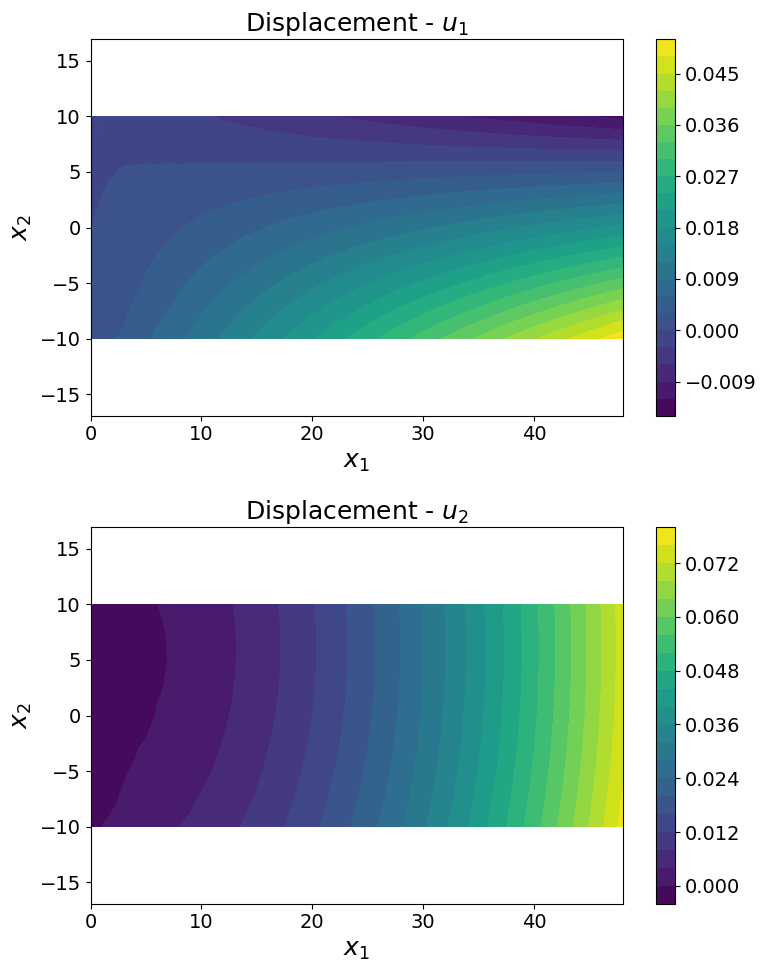

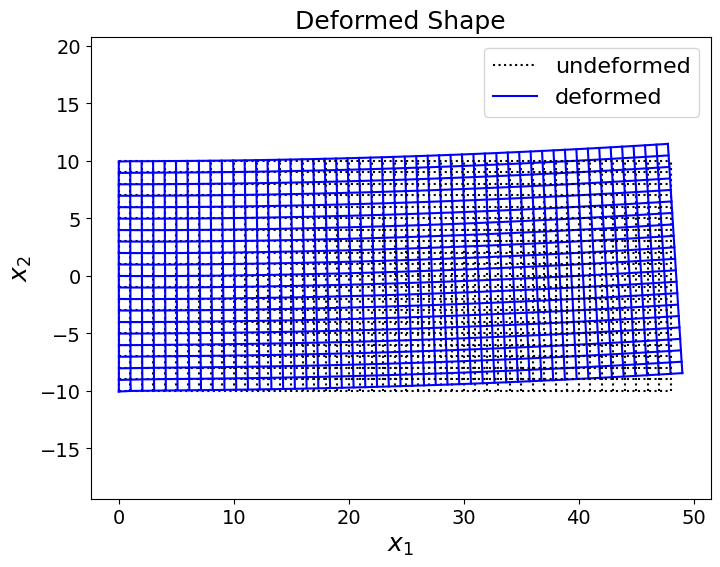

In [ ]:
# Plots
L = 48.0
W = 20.0

# Contour plots
plot_displacement_contours(u_grid, L, W)

# Deformed shape
plot_deformed_shape(u_grid, L, W, scale=20.0)

In [ ]:
def plot_traction_field(tensor, L, W):
    """
    Plots contour maps of traction components.

    tensor: [2, nx, ny] traction tensor
    L, W: beam length and width
    """

    tx = tensor[0].cpu()
    ty = tensor[1].cpu()

    nx, ny = tx.shape

    x = torch.linspace(0, L, nx)
    y = torch.linspace(0, W, ny)

    X, Y = torch.meshgrid(x, y, indexing='ij')

    fig, axs = plt.subplots(1, 2, figsize=(12,4))

    c1 = axs[0].contourf(X, Y, tx, levels=20)
    fig.colorbar(c1, ax=axs[0])
    axs[0].set_title("Traction $t_x$")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")

    c2 = axs[1].contourf(X, Y, ty, levels=20)
    fig.colorbar(c2, ax=axs[1])
    axs[1].set_title("Traction $t_y$")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("y")

    plt.tight_layout()
    plt.show()

## Train Model

In [ ]:
# Ridge Optimization CV (Borrowed from course lab sessions)
def cv_optimize_ridge(model, x: np.ndarray, y: np.ndarray, list_of_lambdas: list, n_folds: int=5):
    parameters = {'alpha': list_of_lambdas}
    gs = GridSearchCV(model, param_grid=parameters, cv=n_folds, scoring="neg_mean_squared_error")
    gs.fit(x, y)
    return gs

lambdas = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 1e1, 1e2]

In [ ]:
# Dataset processing for regression
def extract_features(nodes, t):
    return torch.cat([
        nodes.mean(dim=(1,2)),
        nodes.std(dim=(1,2)),
        t.mean(dim=(1,2)),
        t.std(dim=(1,2))
    ])

### Linear Regression

In [ ]:
X_list = []
y_list = []

for nodes, t, u in train_dataset:
    feat = extract_features(nodes, t)
    X_list.append(feat)
    y_list.append(u)

X_train = torch.stack(X_list, dim=0)
y_train = torch.stack(y_list, dim=0)
y_train_flat = y_train.reshape(len(train_dataset), -1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train_flat.shape}")

X_train shape: torch.Size([1464, 8])
y_train shape: torch.Size([1464, 2058])


In [ ]:
X_list = []
y_list = []

for nodes, t, u in test_dataset:
    feat = extract_features(nodes, t)
    X_list.append(feat)
    y_list.append(u)

X_test = torch.stack(X_list, dim=0)
y_test = torch.stack(y_list, dim=0)
y_test_flat = y_test.reshape(len(test_dataset), -1)

In [ ]:
lin_model = linear_model.Ridge()
lin_model_ridge = cv_optimize_ridge(lin_model, X_train.numpy(), y_train_flat.numpy(), lambdas)

### Cubic Regression

In [ ]:
cubic_transform = PolynomialFeatures(degree=3, include_bias=False)
X_train_cubic = cubic_transform.fit_transform(X_train)
X_test_cubic = cubic_transform.transform(X_test)

print(f"X_train_cubic shape: {X_train_cubic.shape}")
print(f"X_test_cubic shape: {X_test_cubic.shape}")

X_train_cubic shape: (1464, 164)
X_test_cubic shape: (366, 164)


In [ ]:
cubic_linear = linear_model.Ridge()
cubic_linear_ridge = cv_optimize_ridge(cubic_linear, X_train_cubic, y_train_flat.numpy(), lambdas)

## Results

### Linear Regression

Ridge(alpha=1e-05) 

{'alpha': 1e-05} 

-0.0010315581224858762 



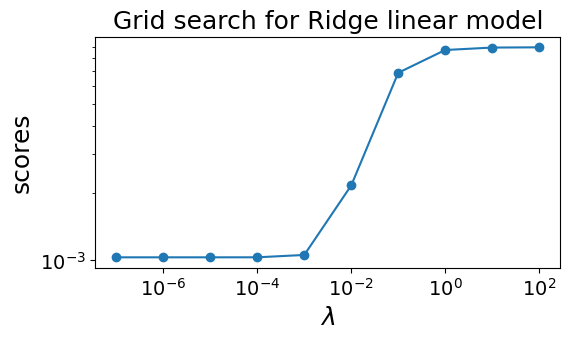

In [ ]:
print(lin_model_ridge.best_estimator_, "\n")
print(lin_model_ridge.best_params_, "\n")
print(lin_model_ridge.best_score_, "\n")

lin_model_ridge.cv_results_
fit_lambdas = [d['alpha'] for d in lin_model_ridge.cv_results_['params']]
fit_scores = lin_model_ridge.cv_results_['mean_test_score']

fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(fit_lambdas, -fit_scores, ls='-', marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.title.set_text('Grid search for Ridge linear model')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('scores')
plt.show()

In [ ]:
# Testing set
y_pred = lin_model_ridge.predict(X_test.numpy())
test_mse = mean_squared_error(y_test_flat.numpy(), y_pred)
print("Testing MSE:", test_mse)

nx = 49
ny = 21

y_pred_tensor = torch.tensor(y_pred, dtype=torch.float32)
y_pred_final = y_pred_tensor.reshape(len(test_dataset), 2, nx, ny)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
y_test_final = y_test_tensor.reshape(len(test_dataset), 2, nx, ny)
t_test_list = [t for nodes,t,u in test_dataset]
t_test = torch.stack(t_test_list, dim=0)

test_res = test_energy_loss(y_pred_final, y_test_final, D, t_test)
print("Testing Energy Loss:", test_res)


Testing MSE: 0.0008300721528939903
Testing Energy Loss: tensor(3.2776)


/tmp/ipykernel_334/11004759.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [ ]:
# Plot testing samples
idx = [187, 0, 261]
samples = [test_dataset[i] for i in idx]
nodes_list, t_list, u_list = zip(*samples)

nodes_test = torch.stack(nodes_list, dim=0).to(device)
t_test = torch.stack(t_list, dim=0).to(device)
u_test = torch.stack(u_list, dim=0).to(device)

u_pred = y_pred_final[idx, :, :, :]

=== Sample 1 ===


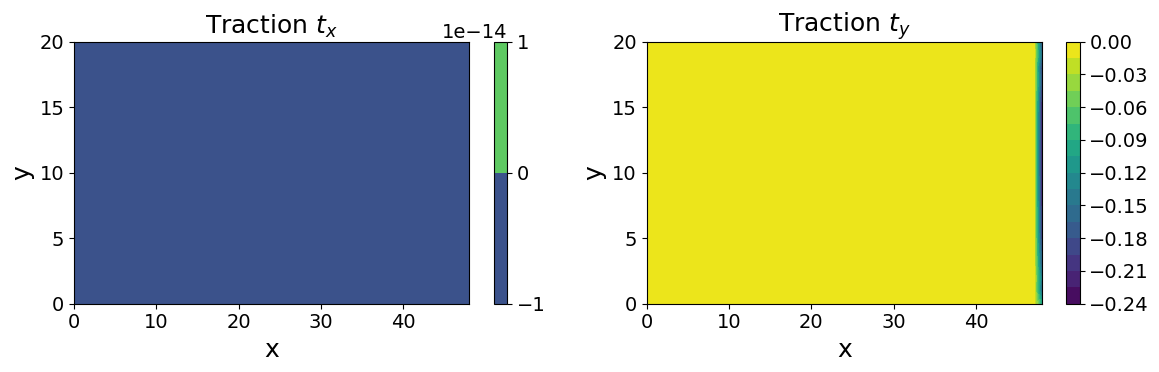

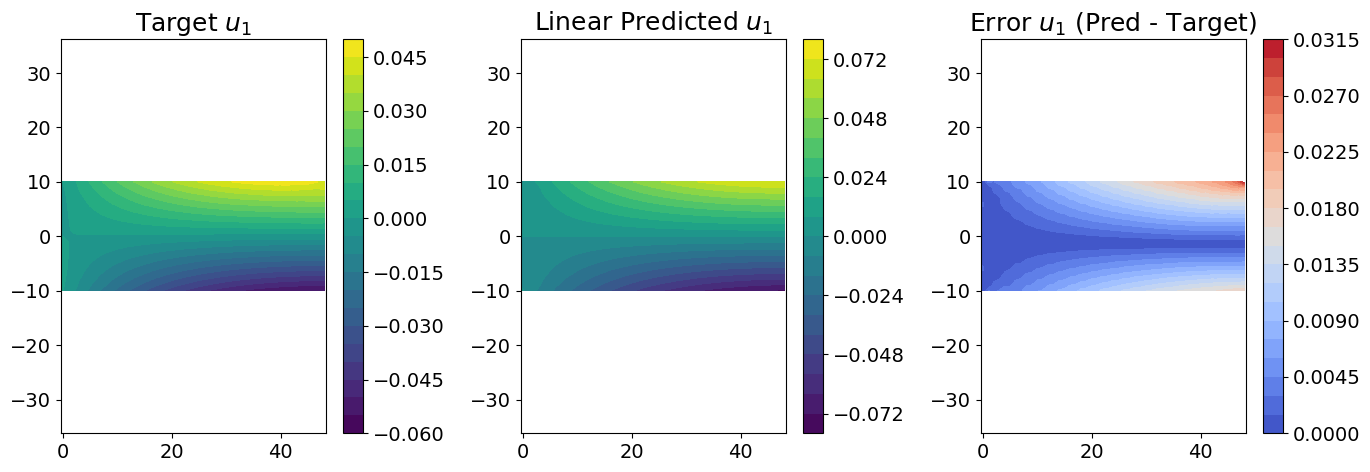

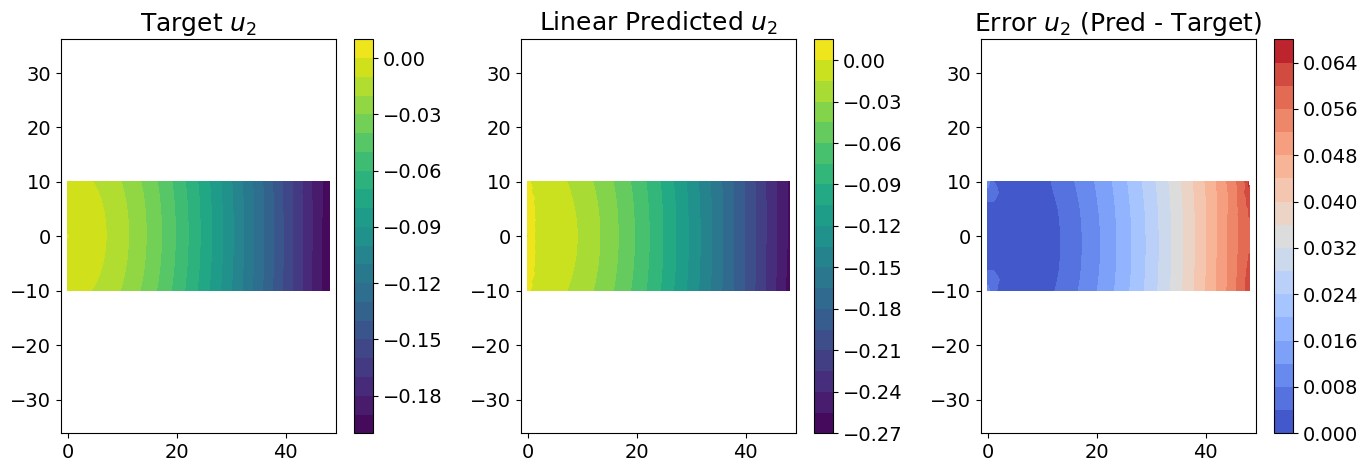

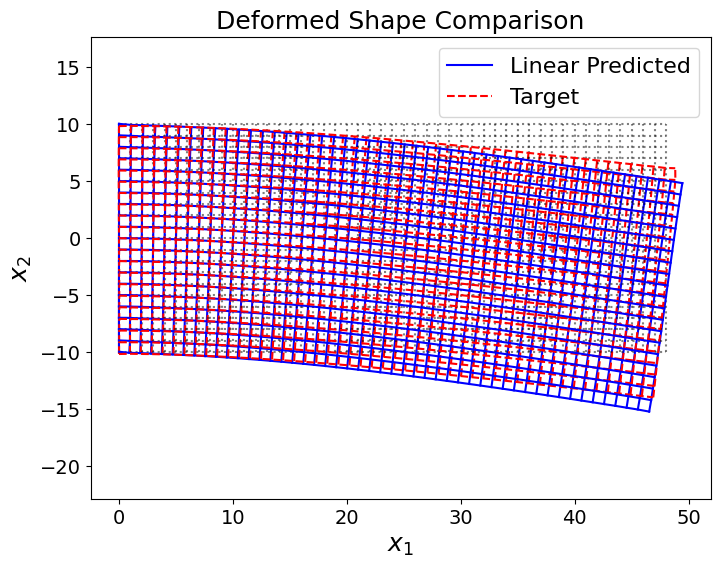

=== Sample 2 ===


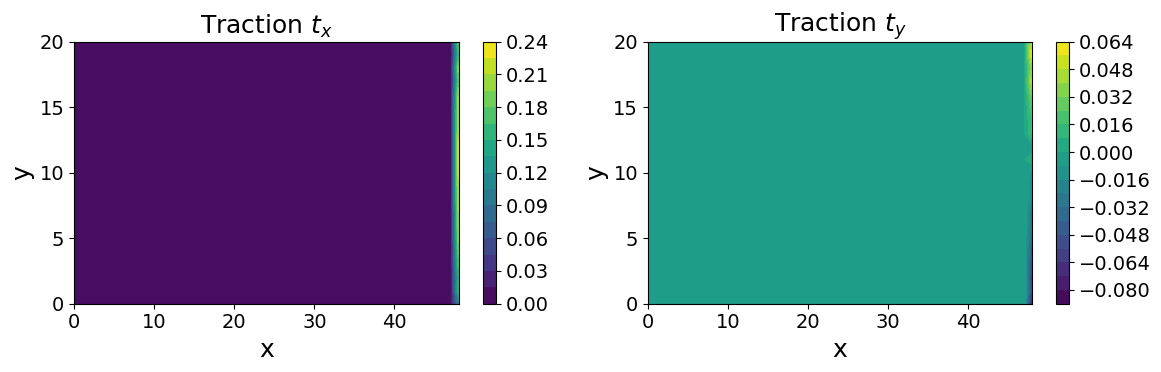

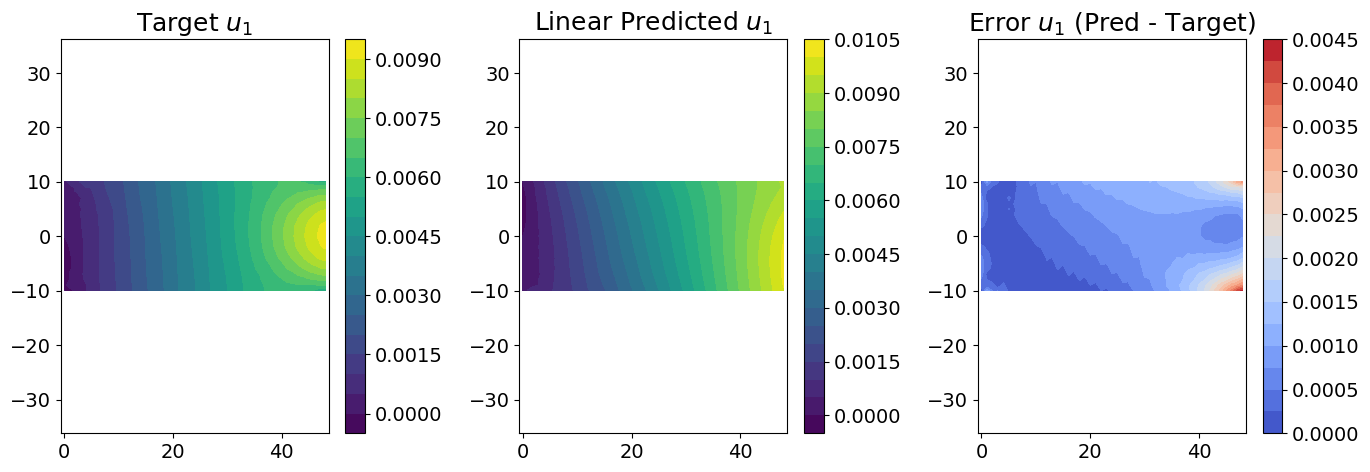

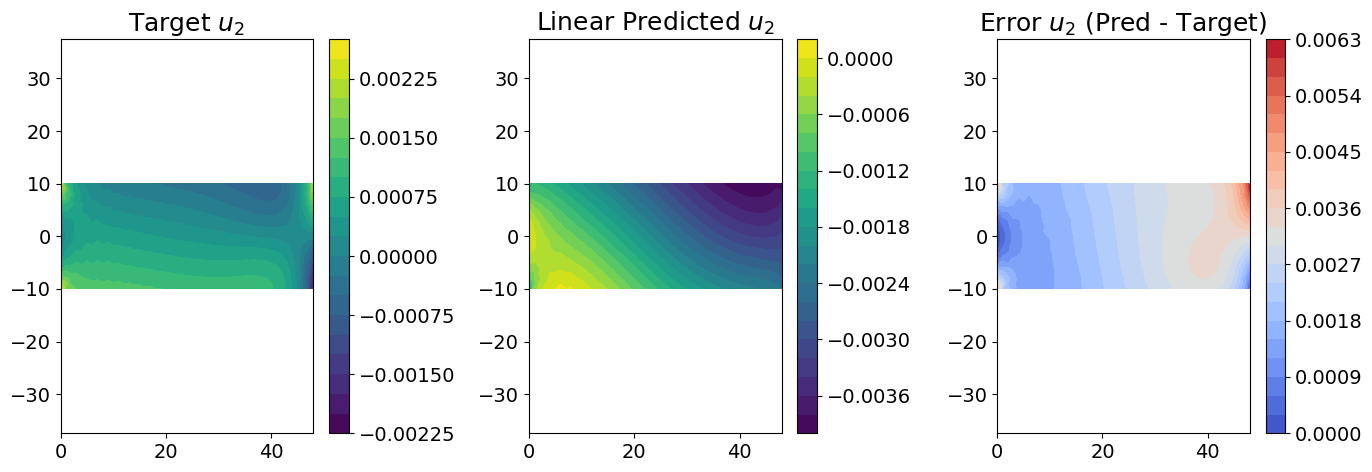

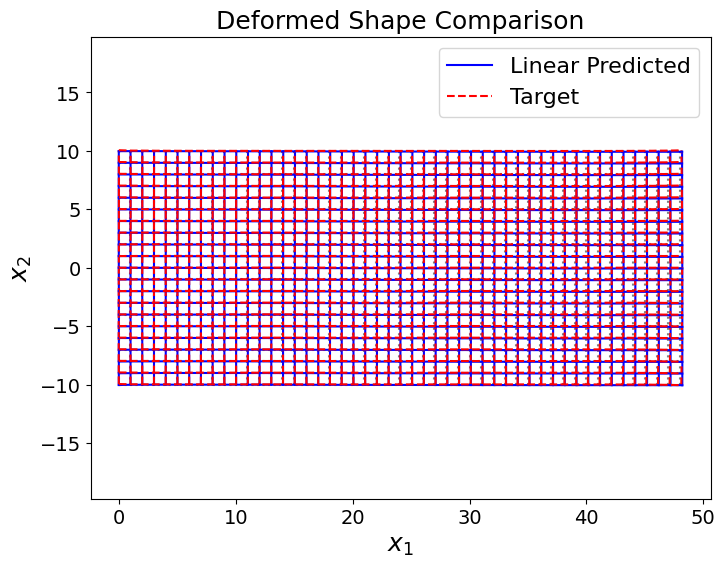

=== Sample 3 ===


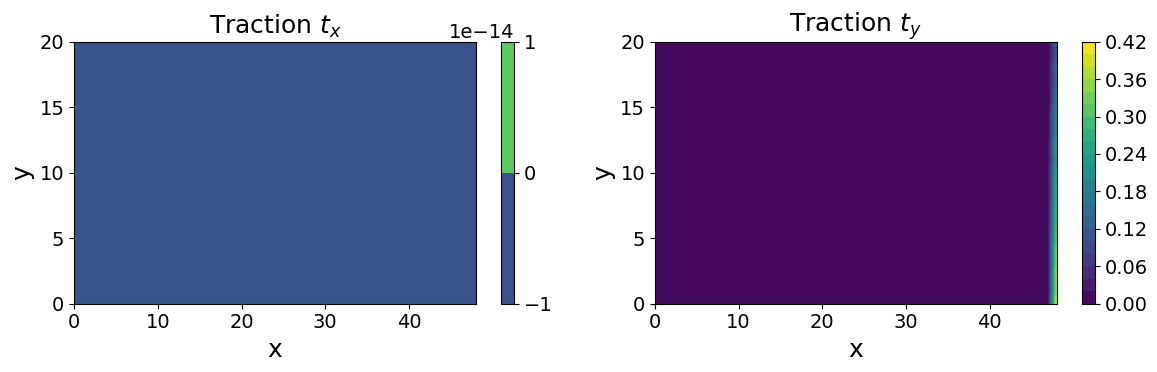

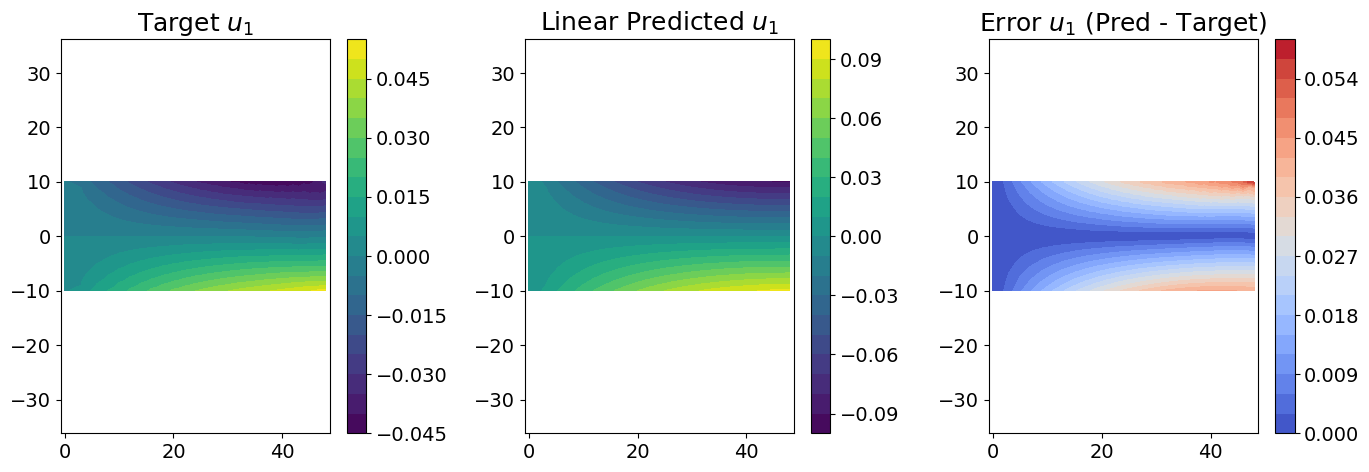

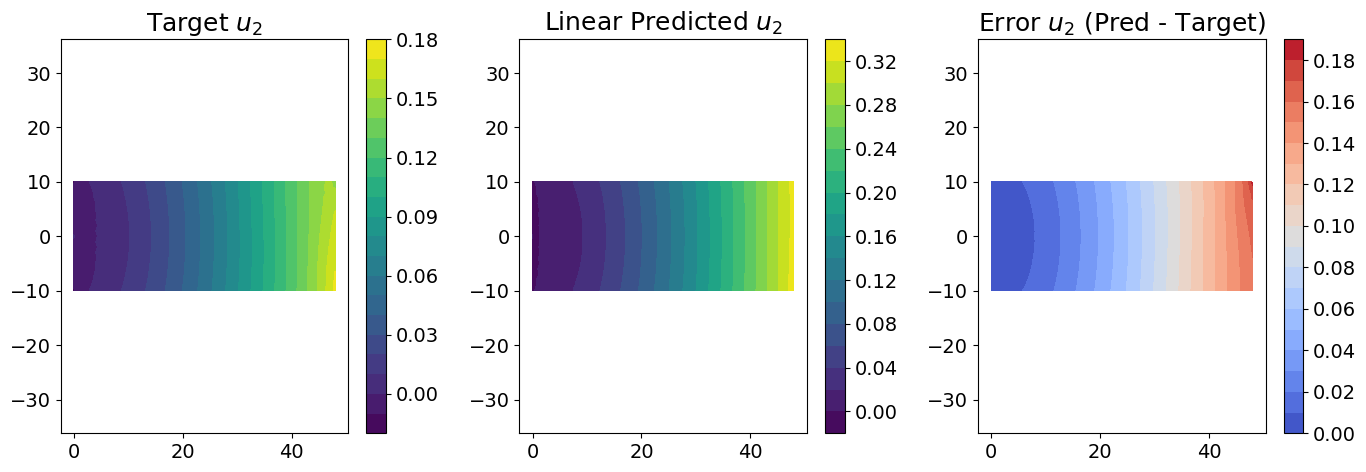

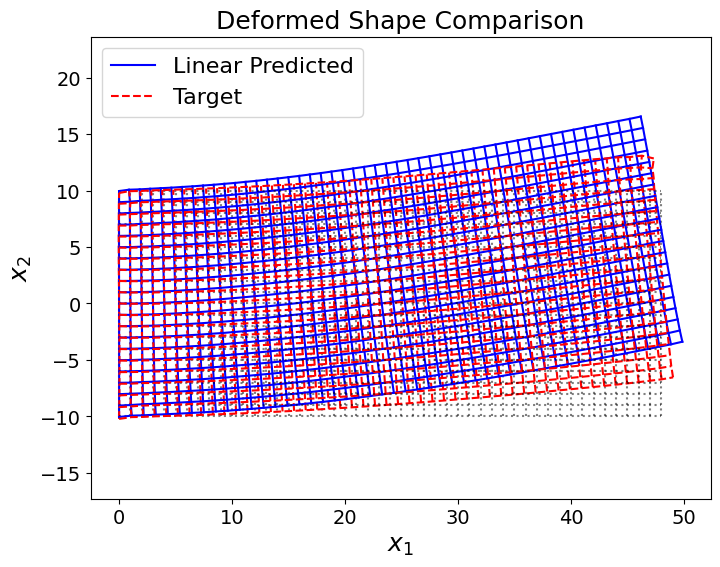

In [ ]:
for i in range(u_pred.shape[0]):
    print(f"=== Sample {i+1} ===")
    u_pred_i = u_pred[i]
    u_target_i = u_test[i]

    # Echo tractions
    t_test_i = t_test[i]
    plot_traction_field(t_test_i, L, W)

    # Plot side-by-side comparison and error
    plot_pred_vs_target(u_pred_i, u_target_i, L, W, "Linear")

    # Plot deformed shape comparison
    plot_deformed_comparison(u_pred_i, u_target_i, L, W, "Linear", scale=20.0)

### Cubic Regression

Ridge(alpha=0.0001) 

{'alpha': 0.0001} 

-0.0010340176270611785 



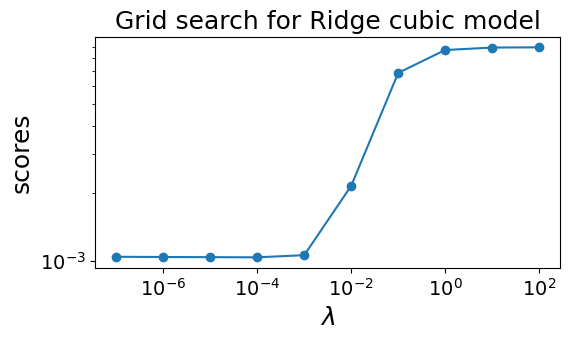

In [ ]:
print(cubic_linear_ridge.best_estimator_, "\n")
print(cubic_linear_ridge.best_params_, "\n")
print(cubic_linear_ridge.best_score_, "\n")

cubic_linear_ridge.cv_results_
fit_lambdas = [d['alpha'] for d in cubic_linear_ridge.cv_results_['params']]
fit_scores = cubic_linear_ridge.cv_results_['mean_test_score']

fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(fit_lambdas, -fit_scores, ls='-', marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.title.set_text('Grid search for Ridge cubic model')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('scores')
plt.show()

In [ ]:
# Testing set
y_pred = cubic_linear_ridge.predict(X_test_cubic)
test_mse = mean_squared_error(y_test_flat.numpy(), y_pred)
print("Testing MSE:", test_mse)

nx = 49
ny = 21

y_pred_tensor = torch.tensor(y_pred, dtype=torch.float32)
y_pred_final = y_pred_tensor.reshape(len(test_dataset), 2, nx, ny)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
y_test_final = y_test_tensor.reshape(len(test_dataset), 2, nx, ny)
t_test_list = [t for nodes,t,u in test_dataset]
t_test = torch.stack(t_test_list, dim=0)
test_res = test_energy_loss(y_pred_final, y_test_final, D, t_test)
print("Testing Energy Loss:", test_res)


Testing MSE: 0.0008277695138447413
Testing Energy Loss: tensor(3.2653)


/tmp/ipykernel_334/1670424714.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [ ]:
# Plot testing samples
idx = [187, 0, 261]
samples = [test_dataset[i] for i in idx]
nodes_list, t_list, u_list = zip(*samples)

nodes_test = torch.stack(nodes_list, dim=0).to(device)
t_test = torch.stack(t_list, dim=0).to(device)
u_test = torch.stack(u_list, dim=0).to(device)

u_pred = y_pred_final[idx, :, :, :]

=== Sample 1 ===


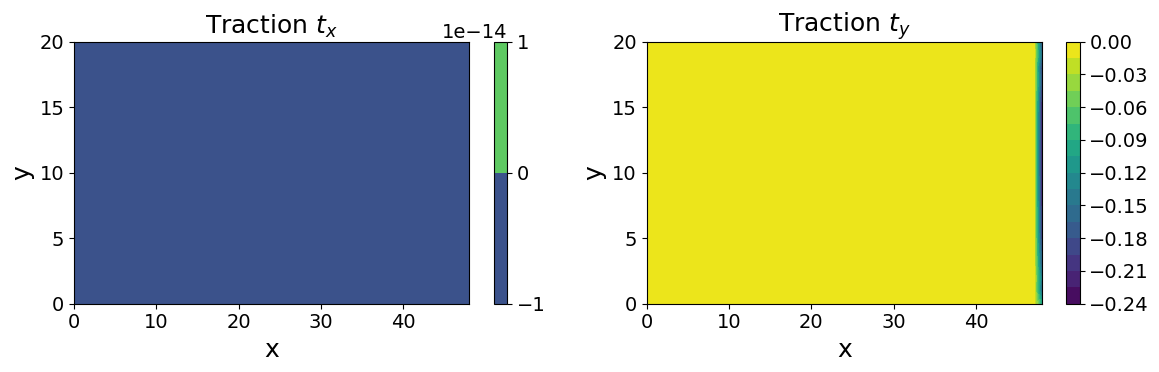

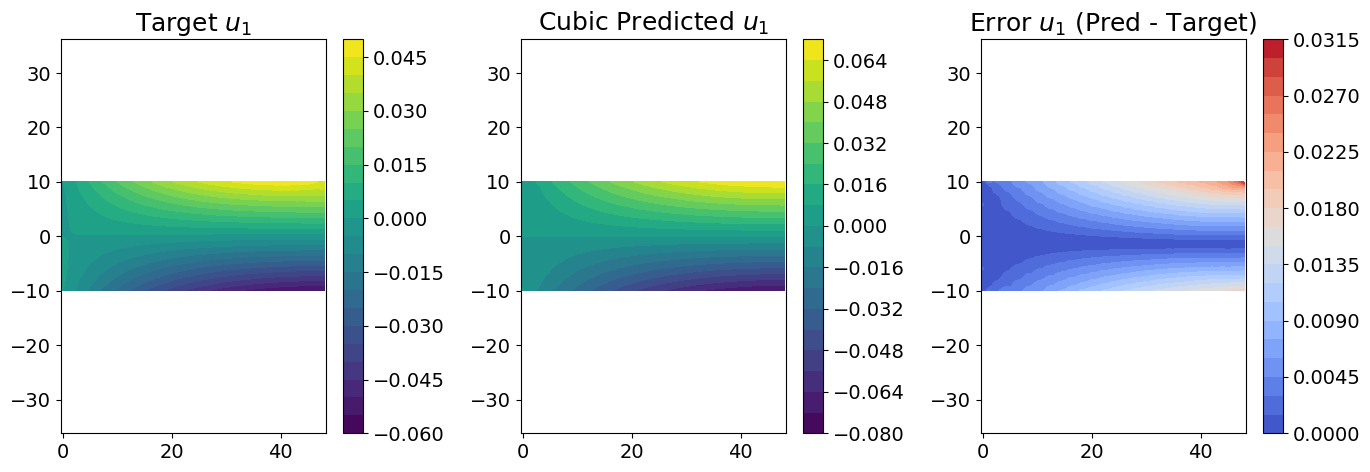

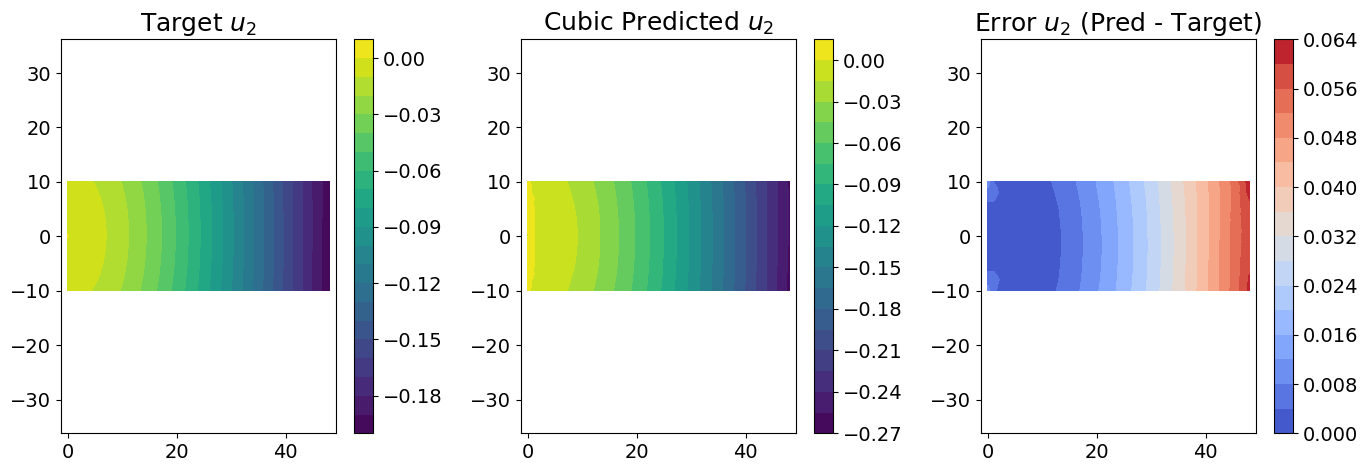

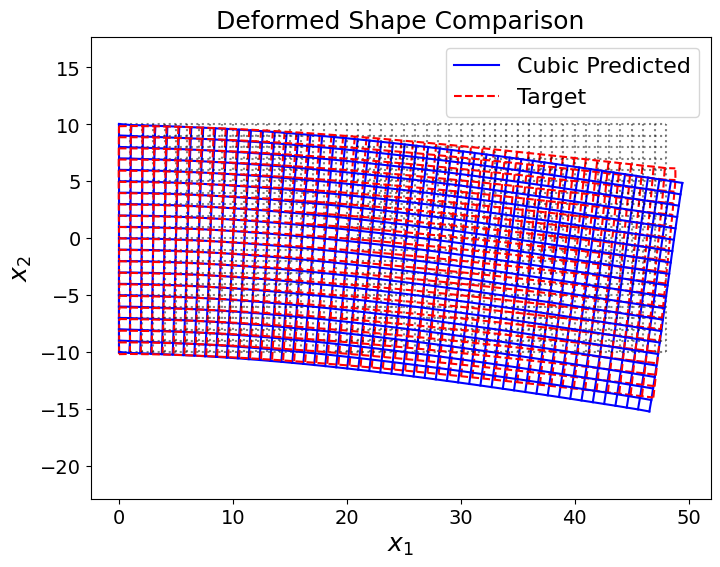

=== Sample 2 ===


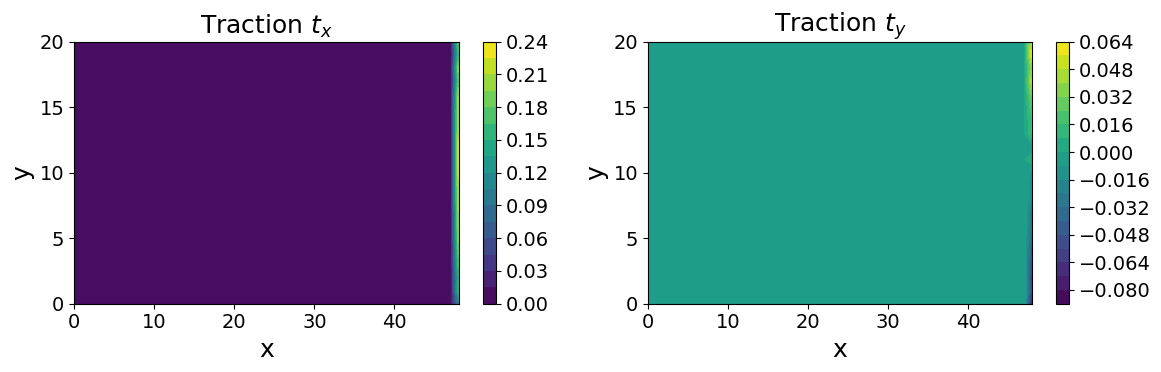

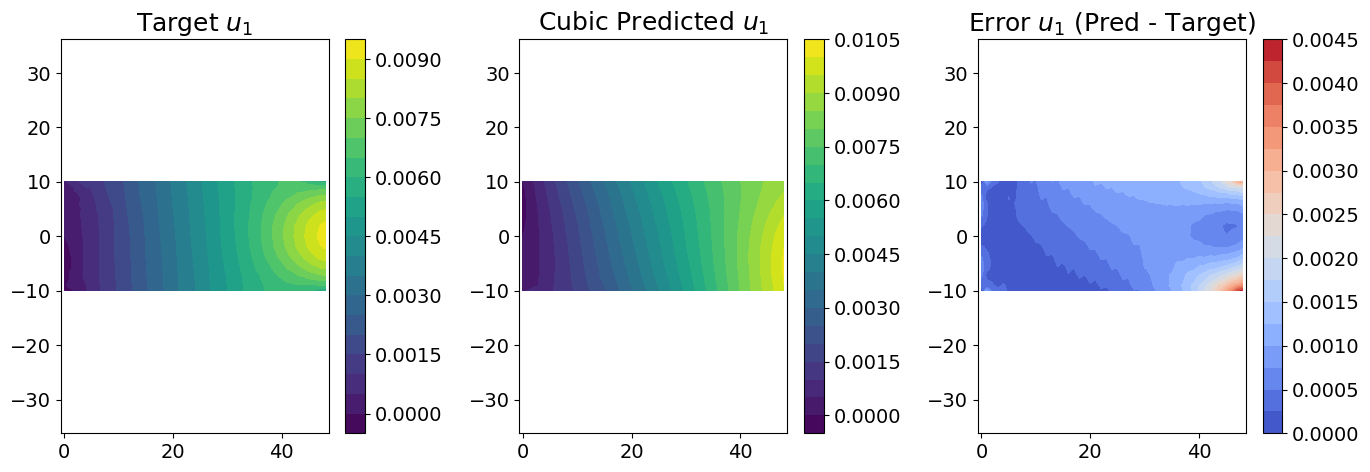

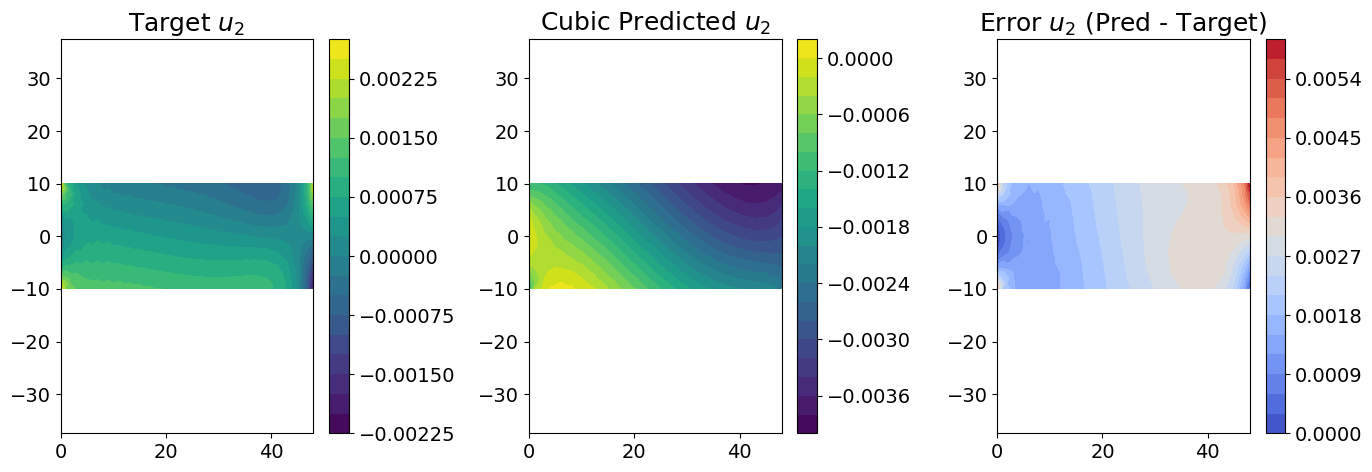

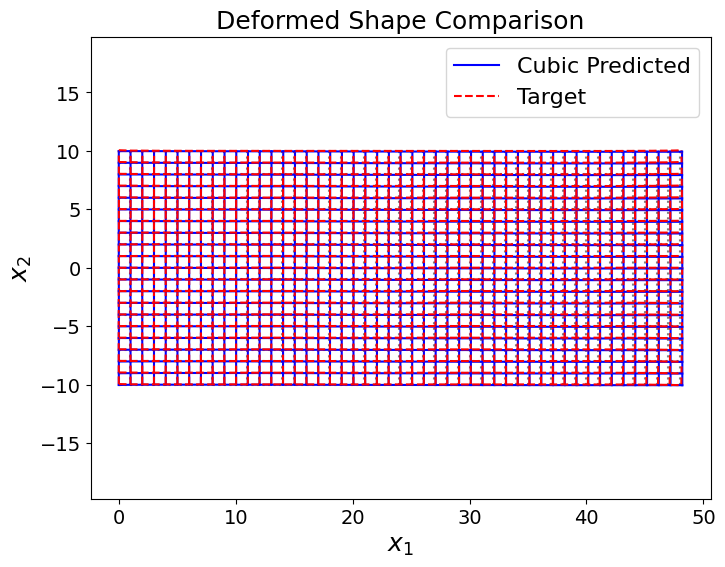

=== Sample 3 ===


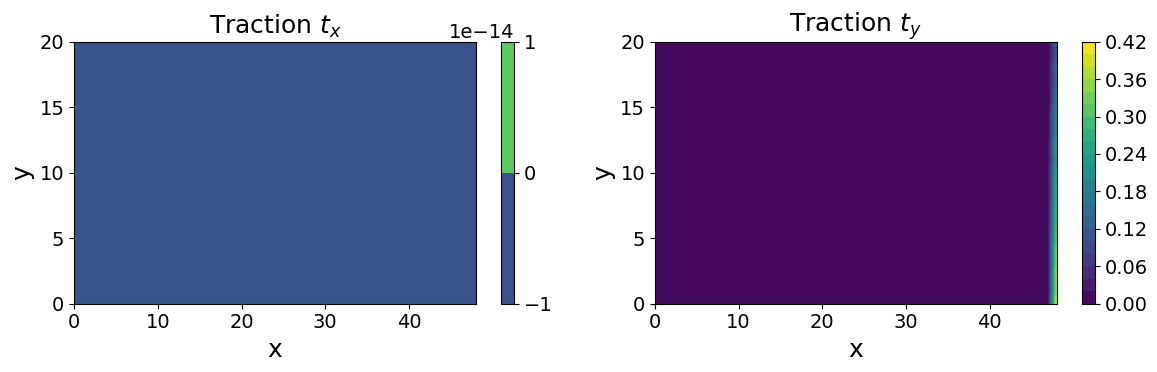

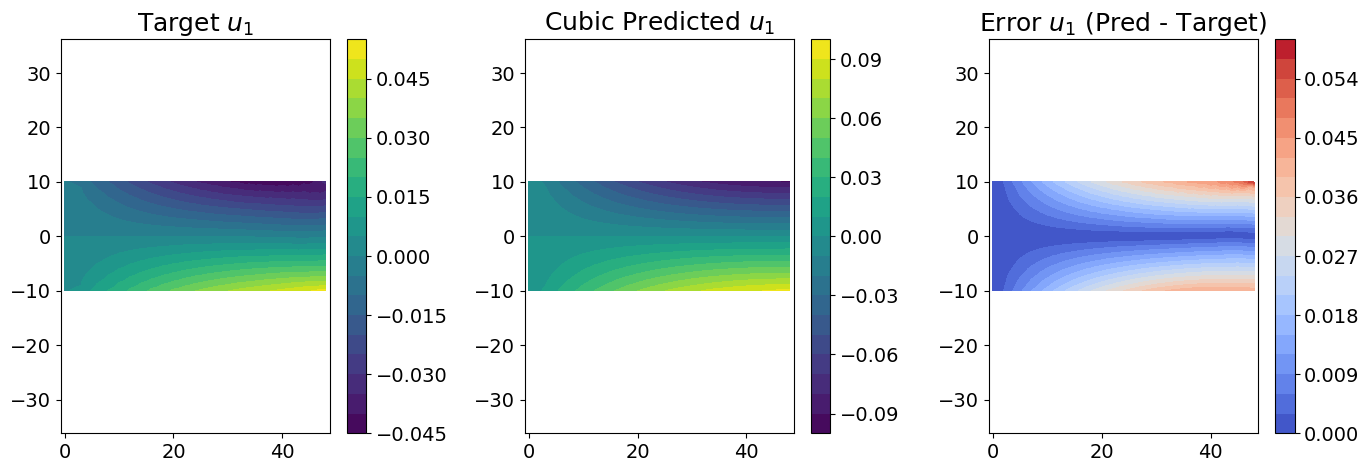

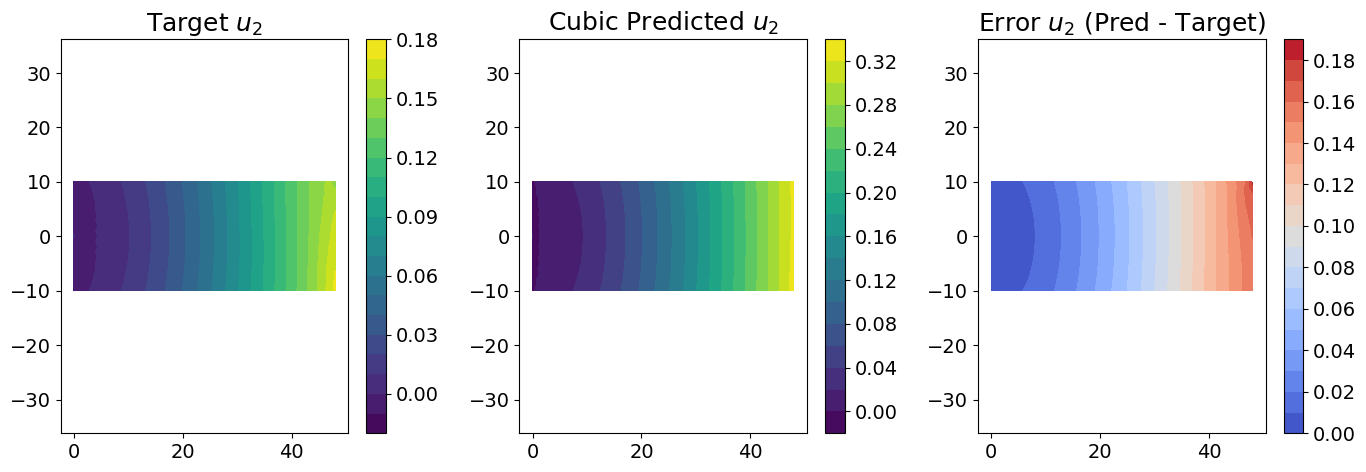

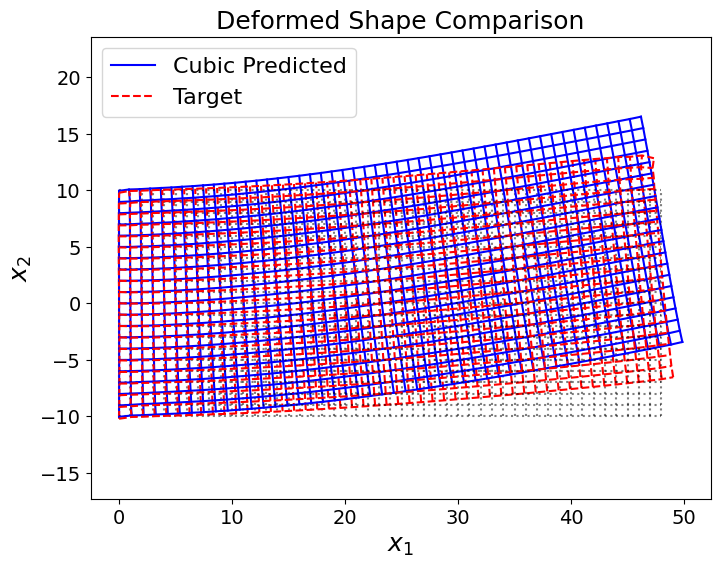

In [ ]:
for i in range(u_pred.shape[0]):
    print(f"=== Sample {i+1} ===")
    u_pred_i = u_pred[i]
    u_target_i = u_test[i]

    # Echo tractions
    t_test_i = t_test[i]
    plot_traction_field(t_test_i, L, W)

    # Plot side-by-side comparison and error
    plot_pred_vs_target(u_pred_i, u_target_i, L, W, "Cubic")

    # Plot deformed shape comparison
    plot_deformed_comparison(u_pred_i, u_target_i, L, W, "Cubic", scale=20.0)

In [ ]:
from google.colab import runtime
runtime.unassign()